In [45]:
%load_ext autoreload
%autoreload 2

import polars as pl
import matplotlib.pyplot as plt
from data.loader import load_bindingdb_data
from data.transform import (
    remove_nulls,
    tranform_ki_to_log_ki,
    train_test_val_split,
    create_pyg_dataset,
    remove_cx_notation,
    tokenize_sequences,
)
from datasets.models import ProteinLigandDataset
from torch_geometric.data import Batch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = load_bindingdb_data()
df.head()

Ligand SMILES,Full_Protein_Sequence,Ki (nM)
str,str,f64
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.24
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.25
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.41
"""OCCCCCCN1[C@H](Cc2ccccc2)[C@H]…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.8
"""OCCCCCN1[C@H](Cc2ccccc2)[C@H](…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.99


In [3]:
def analyze_weird_smiles(df, col_name="Ligand SMILES"):
    weird_df = df.filter(pl.col(col_name).str.contains(r"\|"))

    total_records = df.height
    weird_count = weird_df.height
    percentage = (weird_count / total_records) * 100

    unique_weird = weird_df.select(col_name).unique()

    print("--- Analiza formatu CXSMILES ---")
    print(f"Suma wszystkich rekordów: {total_records}")
    print(f"Liczba rekordów z '|...|': {weird_count} ({percentage:.2f}%)")
    print(f"Liczba unikalnych struktur z tym zapisem: {unique_weird.height}")
    print("-" * 32)

    if weird_count > 0:
        print("Przykładowe smilesy z dziwnym zapisem:")
        for s in unique_weird.head(5).to_series():
            print(f"-> {s}")
    else:
        print("Nie znaleziono żadnych rekordów z tym formatem.")

    return unique_weird


# Użycie:
weird_smiles_list = analyze_weird_smiles(df)

--- Analiza formatu CXSMILES ---
Suma wszystkich rekordów: 3048203
Liczba rekordów z '|...|': 704075 (23.10%)
Liczba unikalnych struktur z tym zapisem: 322877
--------------------------------
Przykładowe smilesy z dziwnym zapisem:
-> [#6]\[#6](-[#6])=[#6]/[#6]-[#6][C@@]1([#6])[#6@H](-[#6]\[#6]=[#6](\[#6])-[#6])-[#6][C@@]2([#6]\[#6]=[#6](/[#6])-[#6])[#6](-[#8])=[#6](-[#6](=O)-c3cccc(-[#8])c3)-[#6](=O)[C@]1([#6]\[#6]=[#6](/[#6])-[#6])[#6]2=O |r,t:22,TLB:42:41:14.8.6:23.21.33|
-> CC(=NNC(=O)c1ccc(Br)cc1O)c1cc2ccccc2[nH]1 |w:2.2|
-> OC1CNC=Nc2c1ncn2CCCc1ccc(o1)C(O)=O |c:4|
-> CCOCCNc1ncc2cc(-c3c(Cl)c(OC)cc(OC)c3Cl)c(=O)n(CCCN3CCN(CC3)C(=O)C=C)c2n1 |(-8,-5.39,;-8,-3.85,;-6.67,-3.08,;-6.67,-1.54,;-5.33,-.77,;-5.33,.77,;-4,1.54,;-4,3.08,;-2.67,3.85,;-1.33,3.08,;,3.85,;1.33,3.08,;2.67,3.85,;2.67,5.39,;1.33,6.16,;4,6.16,;4,7.7,;2.67,8.47,;5.33,5.39,;5.33,3.85,;6.67,3.08,;8,3.85,;4,3.08,;4,1.54,;1.33,1.54,;2.67,.77,;,.77,;,-.77,;1.33,-1.54,;1.33,-3.08,;2.67,-3.85,;2.67,-5.39,;4,-6.16,;5.33,-5.39

In [4]:
df = remove_cx_notation(df)
analyze_weird_smiles(df)

--- Analiza formatu CXSMILES ---
Suma wszystkich rekordów: 3048203
Liczba rekordów z '|...|': 0 (0.00%)
Liczba unikalnych struktur z tym zapisem: 0
--------------------------------
Nie znaleziono żadnych rekordów z tym formatem.


Ligand SMILES
str


In [5]:
df["Ki (nM)"].describe()

statistic,value
str,f64
"""count""",602943.0
"""null_count""",2.44526e6
"""mean""",331809.165733
"""std""",1.1719e7
"""min""",0.0
"""25%""",8.1
"""50%""",100.0
"""75%""",1441.0
"""max""",4.0000e9


In [6]:
df = remove_nulls(df)
df = tranform_ki_to_log_ki(df)
df["pKi"].describe()

statistic,value
str,f64
"""count""",602943.0
"""null_count""",0.0
"""mean""",6.969321
"""std""",1.537736
"""min""",4.0
"""25%""",5.841451
"""50%""",7.0
"""75%""",8.091515
"""max""",14.0


In [7]:
df = df.with_columns([(pl.col("pKi") >= 7).alias("is_active")])
df["is_active"].value_counts()

is_active,count
bool,u32
true,306247
false,296696


In [ ]:
VOCAB_SEQUENCE = set("".join(df["Full_Protein_Sequence"].str.to_uppercase().to_list()))
VOCAB_SIZE = len(VOCAB_SEQUENCE)
char_to_idx = {char: idx for idx, char in enumerate(sorted(VOCAB_SEQUENCE))}
df = tokenize_sequences(df, char_to_idx)

In [9]:
train_df, val_df, test_df = train_test_val_split(df)
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)
train_df["Ligand SMILES"]

(425469, 6)
(58301, 6)
(119173, 6)


Ligand SMILES
str
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…"
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…"
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…"
"""OCCCCCN1[C@H](Cc2ccccc2)[C@H](…"
"""OCCCCCN1[C@H](Cc2ccccc2)[C@H](…"
…
"""O[C@@H](CNCCCCOC(=O)c1coc(COc2…"
"""O[C@@H](CNCCCCOC(=O)c1cccc(COc…"
"""COc1cc(ccc1COc1cccc(c1)[C@@H](…"


In [10]:
all_unique_smiles = df["Ligand SMILES"].unique().to_list()

all_graphs = create_pyg_dataset(all_unique_smiles, with_features=False)
global_smiles_map = dict(zip(all_unique_smiles, all_graphs))

Konwersja 244788 SMILES na grafy (with_features=False)...


[18:41:57] Explicit valence for atom # 17 N, 4, is greater than permitted
[18:42:00] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[18:42:04] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13 23 24
[18:42:04] Explicit valence for atom # 8 N, 4, is greater than permitted
[18:42:09] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[18:42:14] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[18:42:17] Explicit valence for atom # 17 N, 4, is greater than permitted
[18:42:19] Explicit valence for atom # 19 O, 3, is greater than permitted
[18:42:19] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[18:42:23] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 18 19 20 21
[18:42:23] Explicit valence for atom # 20 O, 3, is greater than permitted
[18:42:24] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[18:42:29] Explicit valence for atom # 13 N, 4, is greater than permitted
[18:42:35] Explicit valence for atom # 19 O, 3, is greater than permitted
[

In [11]:
valid_keys = set(global_smiles_map.keys())
print(f"Liczba poprawnych grafów w słowniku: {len(valid_keys)}")

train_df = train_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))
val_df = val_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))
test_df = test_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))

print(f"Rekordy w treningu po synchronizacji: {train_df.height}")
print(f"Rekordy w walidacji po synchronizacji: {val_df.height}")
print(f"Rekordy w teście po synchronizacji: {test_df.height}")

Liczba poprawnych grafów w słowniku: 244744
Rekordy w treningu po synchronizacji: 425394
Rekordy w walidacji po synchronizacji: 58293
Rekordy w teście po synchronizacji: 119165


In [22]:
train_dataset = ProteinLigandDataset(train_df, global_smiles_map)
assert (
    len(train_dataset.smiles) == len(train_dataset.sequences) == len(train_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"
test_dataset = ProteinLigandDataset(test_df, global_smiles_map)
assert (
    len(test_dataset.smiles) == len(test_dataset.sequences) == len(test_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"

val_dataset = ProteinLigandDataset(val_df, global_smiles_map)
assert (
    len(val_dataset.smiles) == len(val_dataset.sequences) == len(val_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"

In [39]:
from torch_geometric.nn import global_add_pool
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class ProteinLigandModel(nn.Module):
    def __init__(self, vocab_size, gcn_hidden=256, cnn_filters=128, embed_dim=256, dropout=0.3):
        super().__init__()

        # --- Gałąź GCN (dla SMILES) ---
        self.atom_embedding = nn.Embedding(120, gcn_hidden)
        self.gcn_convs = nn.ModuleList([GCNConv(gcn_hidden, gcn_hidden) for _ in range(3)])
        self.gcn_bns = nn.ModuleList([nn.BatchNorm1d(gcn_hidden) for _ in range(3)])

        # --- Gałąź CNN (dla sekwencji) ---
        self.seq_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv3 = self._conv_block(embed_dim, cnn_filters, kernel=3)
        self.conv7 = self._conv_block(embed_dim, cnn_filters, kernel=7)
        self.conv15 = self._conv_block(embed_dim, cnn_filters, kernel=15)

        # --- Klasyfikator (łączy obie gałęzie) ---
        combined_dim = gcn_hidden + 3 * cnn_filters
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def _conv_block(self, in_ch, out_ch, kernel):
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )

    def _masked_pool(self, x, mask):
        x = x.masked_fill(mask == 0, float("-inf"))
        return x.max(dim=2).values

    def forward(self, graph_batch, seq_batch):
        # --- GCN ---
        x = graph_batch.x[:, 0].long()
        x = self.atom_embedding(x)
        for conv, bn in zip(self.gcn_convs, self.gcn_bns):
            x = F.leaky_relu(bn(conv(x, graph_batch.edge_index)))
        graph_emb = global_add_pool(x, graph_batch.batch)  # (B, gcn_hidden)

        # --- CNN ---
        mask = (seq_batch != 0).unsqueeze(1).float()
        s = self.seq_embedding(seq_batch).transpose(1, 2)
        out3 = self._masked_pool(self.conv3(s), mask)
        out7 = self._masked_pool(self.conv7(s), mask)
        out15 = self._masked_pool(self.conv15(s), mask)
        seq_emb = torch.cat([out3, out7, out15], dim=1)  # (B, 3*cnn_filters)

        # --- Połączenie i klasyfikacja ---
        combined = torch.cat([graph_emb, seq_emb], dim=1)  # (B, gcn_hidden + 3*cnn_filters)
        return self.classifier(combined)

In [40]:
from tqdm import tqdm


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for graph_batch, seq_batch, y in pbar:
        graph_batch = graph_batch.to(device)
        seq_batch = seq_batch.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(graph_batch, seq_batch).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [41]:
def collate_fn(batch):
    graphs, seqs, labels = zip(*batch)
    graph_batch = Batch.from_data_list(graphs)
    seq_batch = pad_sequence(seqs, batch_first=True, padding_value=0)
    label_batch = torch.stack(labels)
    return graph_batch, seq_batch, label_batch

In [42]:
model = ProteinLigandModel(vocab_size=len(char_to_idx) + 1)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True,
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ProteinLigandModel(
  (atom_embedding): Embedding(120, 256)
  (gcn_convs): ModuleList(
    (0-2): 3 x GCNConv(256, 256)
  )
  (gcn_bns): ModuleList(
    (0-2): 3 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (seq_embedding): Embedding(25, 256, padding_idx=0)
  (conv3): Sequential(
    (0): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (conv7): Sequential(
    (0): Conv1d(256, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=

In [46]:
@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc="Val  ", leave=False)
    for graph_batch, seq_batch, y in pbar:
        graph_batch = graph_batch.to(device)
        seq_batch = seq_batch.to(device)
        y = y.to(device)

        logits = model(graph_batch, seq_batch).squeeze(1)
        total_loss += criterion(logits, y).item()

        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    all_preds = (np.array(all_probs) > 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader),
        "auc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),  # AUC-PR, lepsza przy niezbalansowanych danych
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }
    return metrics

In [ ]:
from sklearn.metrics import roc_auc_score

import warnings

warnings.filterwarnings("ignore", module="torch.utils.data.dataloader")


def train_loop(model, train_loader, val_loader, optimizer, criterion, device, epochs=50):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_auc = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        # --- Trening ---
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)

        # --- Walidacja ---
        val_loss, val_auc = eval_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")

        # --- Zapis najlepszego modelu ---
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            torch.save(model.state_dict(), "best_model.pt")
            print(f"  ✓ Nowy najlepszy model (epoch {epoch}, val_auc={val_auc:.4f})")

        # --- Early stopping ---
        if epoch - best_epoch >= 15:
            print(f"Early stopping — brak poprawy od {15} epok")
            break

    print(f"\nNajlepszy model: epoch {best_epoch}, val_auc={best_val_auc:.4f}")

    # --- Załaduj najlepszy model i oceń na teście ---
    model.load_state_dict(torch.load("best_model.pt"))
    return model


# Uruchomienie
model = train_loop(model, train_loader, val_loader, optimizer, criterion, device, epochs=50)

Train:   0%|          | 0/6647 [00:00<?, ?it/s]

Train:  90%|████████▉ | 5977/6647 [04:18<00:29, 23.01it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f82dd8a0860>
Traceback (most recent call last):
  File "/home/kstankiewicz/DTI/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/kstankiewicz/DTI/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f82dd8a0860>
Traceback (most recent call last):
  File "/h

Epoch 001 | train_loss=0.6059 | val_loss=0.5911 | val_auc=0.7424
  ✓ Nowy najlepszy model (epoch 1, val_auc=0.7424)


Epoch 002 | train_loss=0.5906 | val_loss=0.5869 | val_auc=0.7485
  ✓ Nowy najlepszy model (epoch 2, val_auc=0.7485)


Epoch 003 | train_loss=0.5857 | val_loss=0.5842 | val_auc=0.7499
  ✓ Nowy najlepszy model (epoch 3, val_auc=0.7499)


...

Epoch 022 | train_loss=0.5533 | val_loss=0.5907 | val_auc=0.7476


Epoch 023 | train_loss=0.5515 | val_loss=0.5941 | val_auc=0.7471


Epoch 024 | train_loss=0.5509 | val_loss=0.5931 | val_auc=0.7473
Early stopping — brak poprawy od 15 epok

Najlepszy model: epoch 9, val_auc=0.7526


Test | loss=0.5810 | auc=0.7523


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f82dd8a0860>
Traceback (most recent call last):
  File "/home/kstankiewicz/DTI/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/kstankiewicz/DTI/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f82dd8a0860>
Traceback (most recent call last):
  File "/home/kstankiewicz/DTI/Multimodal-models-for-predicting-drug

In [48]:
# Ewaluacja na zbiorze testowym
val_metrics = eval_epoch(model, test_loader, criterion, device)
print(
    f"val_loss={val_metrics['loss']:.4f} | "
    f"auc={val_metrics['auc']:.4f} | "
    f"auprc={val_metrics['auprc']:.4f} | "
    f"f1={val_metrics['f1']:.4f} | "
    f"precision={val_metrics['precision']:.4f} | "
    f"recall={val_metrics['recall']:.4f}"
)

Val  :   0%|          | 0/1862 [00:00<?, ?it/s]

val_loss=0.5810 | auc=0.7523 | auprc=0.7568 | f1=0.6986 | precision=0.6612 | recall=0.7406


Confusion matrix:   0%|          | 0/1862 [00:00<?, ?it/s]

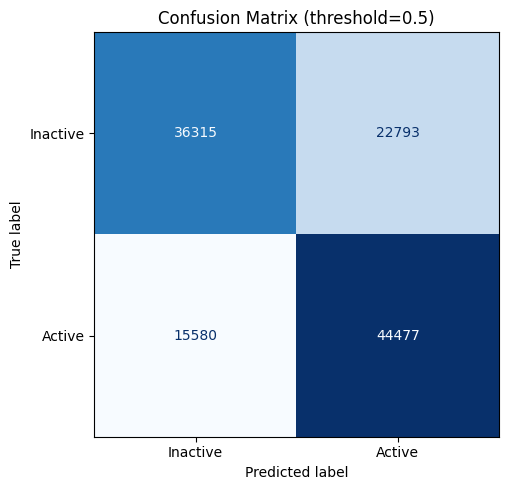

TP=44477 | FP=22793 | FN=15580 | TN=36315
Sensitivity (recall) = 0.7406
Specificity          = 0.6144
Precision            = 0.6612


In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def plot_confusion_matrix(model, loader, device, threshold=0.5):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for graph_batch, seq_batch, y in tqdm(loader, desc="Confusion matrix", leave=False):
            graph_batch = graph_batch.to(device)
            seq_batch = seq_batch.to(device)

            logits = model(graph_batch, seq_batch).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_preds.extend((probs > threshold).astype(int))
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Inactive", "Active"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix (threshold={threshold})")
    plt.tight_layout()
    plt.show()

    # Czytelne podsumowanie tekstowe
    tn, fp, fn, tp = cm.ravel()
    print(f"TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"Sensitivity (recall) = {tp / (tp + fn):.4f}")
    print(f"Specificity          = {tn / (tn + fp):.4f}")
    print(f"Precision            = {tp / (tp + fp):.4f}")


plot_confusion_matrix(model, test_loader, device)